# MBU Gap Analyzer: Deep Learning Edition

## UIDAI Data Hackathon 2026 - Advanced Submission

---

### Upgrade from Standard ML to Deep Learning

This notebook extends the base MBU Gap Analyzer with 4 advanced AI modules:

| Module | Technology | Purpose |
|--------|------------|--------|
| 1 | **LSTM (PyTorch)** | Time-series forecasting for MBU demand prediction |
| 2 | **Autoencoder (PyTorch)** | Unsupervised anomaly detection for suspicious districts |
| 3 | **SHAP** | Explainable AI - why districts are classified as Service Deserts |
| 4 | **Folium** | Interactive geospatial mapping of Service Deserts |

---

## Step 0: Import All Libraries

In [1]:
# ============================================================
# CORE LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import os
import glob

# ============================================================
# VISUALIZATION
# ============================================================
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = "plotly_white"
from IPython.display import display, HTML, Image

def show_fig(fig, height=600):
    """Display plotly figure using PNG rendering."""
    try:
        img_bytes = fig.to_image(format="png", width=1200, height=height, scale=2)
        display(Image(img_bytes))
    except Exception as e:
        fig.write_html("analysis_outputs/temp_chart.html")
        print(f"[Chart saved to analysis_outputs/temp_chart.html]")

# ============================================================
# MACHINE LEARNING (Scikit-Learn)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

# ============================================================
# DEEP LEARNING (PyTorch)
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[PyTorch] Using device: {device}")
if device.type == 'cuda':
    print(f"[GPU] {torch.cuda.get_device_name(0)}")

# ============================================================
# EXPLAINABLE AI
# ============================================================
import shap

# ============================================================
# GEOSPATIAL
# ============================================================
import folium
from folium.plugins import MarkerCluster

print("[OK] All libraries loaded successfully")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

[PyTorch] Using device: cpu
[OK] All libraries loaded successfully
Analysis Date: 2026-01-20


## Step 1: Load and Preprocess Data (Same as Base Notebook)

In [2]:
# Define base path
BASE_PATH = r"uidai_datasets"

def load_all_csvs(folder_path, dataset_name):
    """Load and concatenate all CSV files from a folder."""
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    print(f"Loading {len(all_files)} files from {dataset_name}...")
    
    dfs = []
    for file in all_files:
        df = pd.read_csv(file)
        dfs.append(df)
        print(f"   - Loaded: {os.path.basename(file)} ({len(df):,} rows)")
    
    combined = pd.concat(dfs, ignore_index=True)
    print(f"   Total: {len(combined):,} records\n")
    return combined

# Load all datasets
print("="*60)
print("LOADING UIDAI DATASETS")
print("="*60 + "\n")

df_enrolment = load_all_csvs(
    os.path.join(BASE_PATH, "api_data_aadhar_enrolment"), 
    "Enrolment Data"
)

df_biometric = load_all_csvs(
    os.path.join(BASE_PATH, "api_data_aadhar_biometric"), 
    "Biometric Update Data"
)

df_demographic = load_all_csvs(
    os.path.join(BASE_PATH, "api_data_aadhar_demographic"), 
    "Demographic Update Data"
)

print("="*60)
print("[OK] ALL DATASETS LOADED SUCCESSFULLY")
print("="*60)

LOADING UIDAI DATASETS

Loading 3 files from Enrolment Data...
   - Loaded: api_data_aadhar_enrolment_0_500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_enrolment_1000000_1006029.csv (6,029 rows)
   - Loaded: api_data_aadhar_enrolment_500000_1000000.csv (500,000 rows)
   Total: 1,006,029 records

Loading 4 files from Biometric Update Data...
   - Loaded: api_data_aadhar_biometric_0_500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_biometric_1000000_1500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_biometric_1500000_1861108.csv (361,108 rows)
   - Loaded: api_data_aadhar_biometric_500000_1000000.csv (500,000 rows)
   Total: 1,861,108 records

Loading 5 files from Demographic Update Data...
   - Loaded: api_data_aadhar_demographic_0_500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_demographic_1000000_1500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_demographic_1500000_2000000.csv (500,000 rows)
   - Loaded: api_data_aadhar_demographic_2000000_2071700.csv (71

In [3]:
# Preprocess datasets
def preprocess_dataset(df, name):
    print(f"\nPreprocessing: {name}")
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['year_month'] = df['date'].dt.to_period('M')
    return df

df_enrolment = preprocess_dataset(df_enrolment, "Enrolment")
df_biometric = preprocess_dataset(df_biometric, "Biometric")
df_demographic = preprocess_dataset(df_demographic, "Demographic")

print("\n[OK] Preprocessing complete")


Preprocessing: Enrolment

Preprocessing: Biometric

Preprocessing: Demographic

[OK] Preprocessing complete


In [4]:
# Create Gap Analysis DataFrame (same logic as base notebook)
enrolment_by_district = df_enrolment.groupby(['state', 'district']).agg({
    'age_0_5': 'sum',
    'age_5_17': 'sum',
    'age_18_greater': 'sum'
}).reset_index()

enrolment_by_district['mbu_eligible'] = (
    enrolment_by_district['age_0_5'] + 
    enrolment_by_district['age_5_17']
)

biometric_by_district = df_biometric.groupby(['state', 'district']).agg({
    'bio_age_5_17': 'sum',
    'bio_age_17_': 'sum'
}).reset_index()

df_gap_analysis = pd.merge(
    enrolment_by_district,
    biometric_by_district,
    on=['state', 'district'],
    how='outer'
).fillna(0)

df_gap_analysis['mbu_compliance_ratio'] = np.where(
    df_gap_analysis['mbu_eligible'] > 0,
    (df_gap_analysis['bio_age_5_17'] / df_gap_analysis['mbu_eligible']) * 100,
    0
).clip(0, 100)

df_gap_analysis['mbu_gap'] = (
    df_gap_analysis['mbu_eligible'] - df_gap_analysis['bio_age_5_17']
).clip(lower=0)

def classify_risk(ratio):
    if ratio >= 80:
        return 'Green (Compliant)'
    elif ratio >= 50:
        return 'Yellow (Moderate Risk)'
    else:
        return 'Red (Service Desert)'

df_gap_analysis['risk_category'] = df_gap_analysis['mbu_compliance_ratio'].apply(classify_risk)

print(f"[OK] Gap Analysis computed for {len(df_gap_analysis)} districts")
print(df_gap_analysis['risk_category'].value_counts())

[OK] Gap Analysis computed for 1109 districts
risk_category
Green (Compliant)         930
Red (Service Desert)      147
Yellow (Moderate Risk)     32
Name: count, dtype: int64


---

# MODULE 1: LSTM Time-Series Forecaster (PyTorch)

## Mathematical Foundation

The LSTM (Long Short-Term Memory) network is designed for sequential data. It maintains a **cell state** $C_t$ and **hidden state** $h_t$ that allow it to learn long-term dependencies.

### LSTM Equations:

**Forget Gate:** $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$

**Input Gate:** $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$

**Candidate Cell:** $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$

**Cell State Update:** $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$

**Output Gate:** $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$

**Hidden State:** $h_t = o_t \odot \tanh(C_t)$

Where $\sigma$ is the sigmoid function and $\odot$ is element-wise multiplication.

---

In [5]:
# ============================================================
# MODULE 1: LSTM TIME-SERIES FORECASTER
# ============================================================
# Goal: Predict future MBU demand to anticipate school admission rush
# Architecture: LSTM -> Fully Connected -> Output
# ============================================================

class MBU_LSTM(nn.Module):
    """
    LSTM Network for MBU Time-Series Forecasting.
    
    Architecture:
        Input (seq_length, 1) -> LSTM (hidden_size) -> FC -> Output (1)
    
    The LSTM learns temporal patterns in biometric update trends,
    enabling prediction of future demand during school admission season.
    """
    
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(MBU_LSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer: Captures sequential dependencies
        # - input_size: Number of features (1 for univariate)
        # - hidden_size: Number of LSTM units
        # - num_layers: Stacked LSTM layers for deeper learning
        # - batch_first: Input shape is (batch, seq, features)
        # - dropout: Regularization between LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully Connected Layer: Maps LSTM output to prediction
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM forward pass
        # out: (batch_size, seq_length, hidden_size) - output for each time step
        # hn: (num_layers, batch_size, hidden_size) - final hidden state
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # Use only the last time step's output for prediction
        out = out[:, -1, :]  # Shape: (batch_size, hidden_size)
        
        # Pass through fully connected layers
        out = self.fc(out)  # Shape: (batch_size, 1)
        
        return out

print("[OK] MBU_LSTM class defined")

[OK] MBU_LSTM class defined


In [6]:
# Prepare Time Series Data for LSTM
print("Preparing time series data for LSTM...\n")

# Aggregate biometric updates by month
monthly_updates = df_biometric.groupby('year_month').agg({
    'bio_age_5_17': 'sum',
    'bio_age_17_': 'sum'
}).reset_index()

monthly_updates['total_updates'] = monthly_updates['bio_age_5_17'] + monthly_updates['bio_age_17_']
monthly_updates['year_month'] = monthly_updates['year_month'].astype(str)
monthly_updates = monthly_updates.sort_values('year_month')

print(f"Monthly data shape: {monthly_updates.shape}")
print(f"Date range: {monthly_updates['year_month'].min()} to {monthly_updates['year_month'].max()}")
display(monthly_updates.head(10))

Preparing time series data for LSTM...

Monthly data shape: (9, 4)
Date range: 2025-03 to 2025-12


,year_month,bio_age_5_17,bio_age_17_,total_updates
0,2025-03,3733578,4588644,8322222
1,2025-04,4356896,4284783,8641679
2,2025-05,3868247,4011709,7879956
3,2025-06,3710149,4189140,7899289
4,2025-07,4499057,5293495,9792552
5,2025-09,3610497,3044431,6654928
6,2025-10,2215380,2367275,4582655
7,2025-11,3608891,3676615,7285506
8,2025-12,4624160,4080148,8704308


In [7]:
def create_sequences(data, seq_length):
    """
    Create input sequences for LSTM training.
    
    For a sequence length of 3:
        Input: [x1, x2, x3] -> Target: x4
        Input: [x2, x3, x4] -> Target: x5
        ... and so on
    
    Args:
        data: Normalized time series values
        seq_length: Number of past time steps to use for prediction
    
    Returns:
        X: Input sequences (n_samples, seq_length, 1)
        y: Target values (n_samples, 1)
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Normalize the data using MinMaxScaler
# LSTM works better with normalized data in range [0, 1]
scaler = MinMaxScaler()
values = monthly_updates['total_updates'].values.reshape(-1, 1)
scaled_values = scaler.fit_transform(values)

# Create sequences with lookback of 3 months
SEQ_LENGTH = 3
X, y = create_sequences(scaled_values, SEQ_LENGTH)

# Reshape for LSTM: (samples, seq_length, features)
X = X.reshape(-1, SEQ_LENGTH, 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split into train/test (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

X shape: (6, 3, 1)
y shape: (6, 1)

Training samples: 4
Testing samples: 2


In [8]:
# ============================================================
# LSTM TRAINING LOOP
# ============================================================
# Loss Function: MSE (Mean Squared Error)
# Optimizer: Adam with learning rate scheduling
# ============================================================

# Initialize model
lstm_model = MBU_LSTM(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

# Loss function: Mean Squared Error
# MSE = (1/n) * Σ(y_pred - y_true)²
criterion = nn.MSELoss()

# Optimizer: Adam (Adaptive Moment Estimation)
# Combines momentum and RMSprop for faster convergence
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

# Learning rate scheduler: Reduce LR when loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# Training parameters
EPOCHS = 100
train_losses = []
test_losses = []

print("Training LSTM Model...")
print("="*50)

for epoch in range(EPOCHS):
    # Training mode
    lstm_model.train()
    optimizer.zero_grad()
    
    # Forward pass
    train_pred = lstm_model(X_train_t)
    train_loss = criterion(train_pred, y_train_t)
    
    # Backward pass (Backpropagation Through Time - BPTT)
    train_loss.backward()
    
    # Gradient clipping to prevent exploding gradients
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
    
    # Update weights
    optimizer.step()
    
    # Evaluation mode
    lstm_model.eval()
    with torch.no_grad():
        test_pred = lstm_model(X_test_t)
        test_loss = criterion(test_pred, y_test_t)
    
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    
    # Update learning rate based on validation loss
    scheduler.step(test_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss.item():.6f} | Test Loss: {test_loss.item():.6f}")

print("\n[OK] LSTM Training Complete!")

Training LSTM Model...
Epoch [20/100] | Train Loss: 0.207067 | Test Loss: 0.224976
Epoch [40/100] | Train Loss: 0.125267 | Test Loss: 0.059563
Epoch [60/100] | Train Loss: 0.143422 | Test Loss: 0.064513
Epoch [80/100] | Train Loss: 0.227053 | Test Loss: 0.057986
Epoch [100/100] | Train Loss: 0.157782 | Test Loss: 0.058850

[OK] LSTM Training Complete!


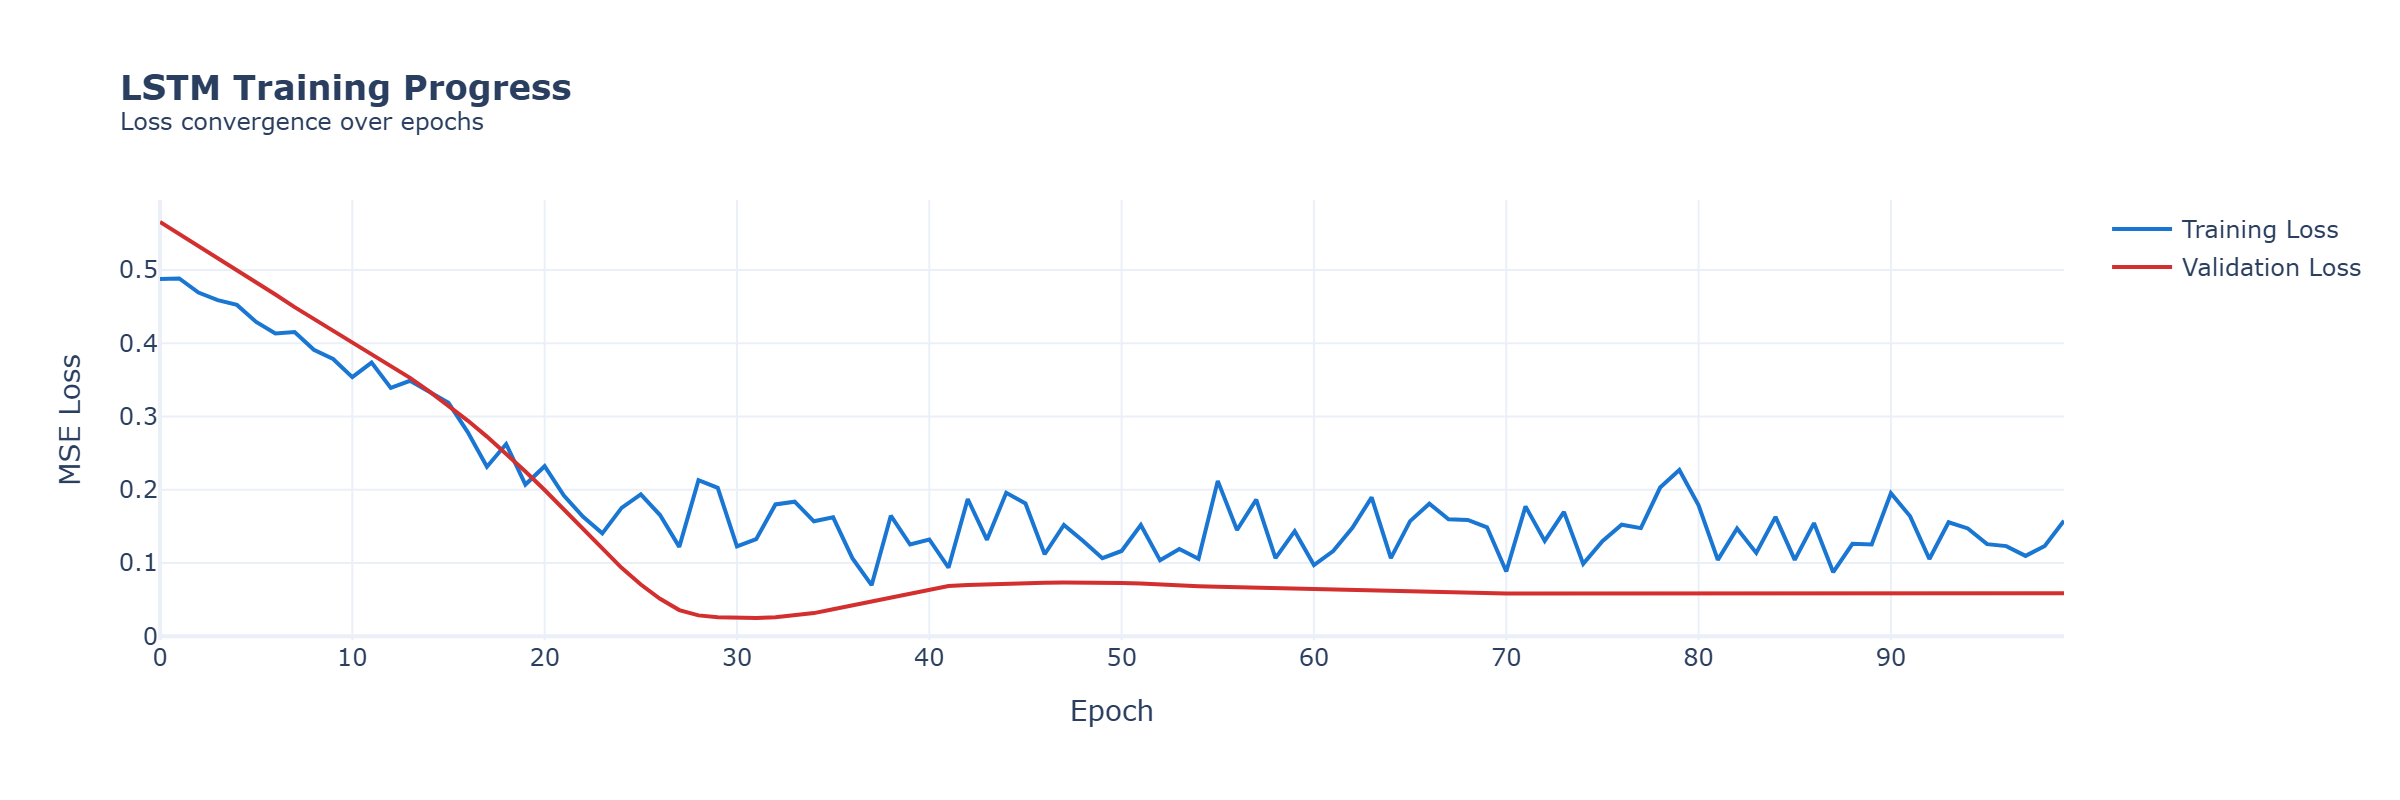

In [9]:
# Plot Training Loss
fig_loss = go.Figure()

fig_loss.add_trace(go.Scatter(
    y=train_losses,
    mode='lines',
    name='Training Loss',
    line=dict(color='#1976d2', width=2)
))

fig_loss.add_trace(go.Scatter(
    y=test_losses,
    mode='lines',
    name='Validation Loss',
    line=dict(color='#d32f2f', width=2)
))

fig_loss.update_layout(
    title='<b>LSTM Training Progress</b><br><sup>Loss convergence over epochs</sup>',
    xaxis_title='Epoch',
    yaxis_title='MSE Loss',
    height=400
)

show_fig(fig_loss, height=400)

In [10]:
# ============================================================
# LSTM FORECASTING - Predict Next 6 Months
# ============================================================

lstm_model.eval()

# Get all predictions (train + test)
with torch.no_grad():
    all_X = torch.FloatTensor(X).to(device)
    all_predictions = lstm_model(all_X).cpu().numpy()

# Forecast future 6 months
future_predictions = []
last_sequence = scaled_values[-SEQ_LENGTH:].reshape(1, SEQ_LENGTH, 1)

for _ in range(6):  # Predict 6 months ahead
    with torch.no_grad():
        input_tensor = torch.FloatTensor(last_sequence).to(device)
        pred = lstm_model(input_tensor).cpu().numpy()[0, 0]
        future_predictions.append(pred)
        
        # Shift window and add prediction
        last_sequence = np.roll(last_sequence, -1, axis=1)
        last_sequence[0, -1, 0] = pred

# Inverse transform predictions
all_predictions_inv = scaler.inverse_transform(all_predictions)
future_predictions_inv = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

print(f"[OK] Forecasted next 6 months")
print(f"Predicted values: {future_predictions_inv.flatten().astype(int)}")

[OK] Forecasted next 6 months
Predicted values: [6965250 7051662 7050228 7003020 7004722 7003525]


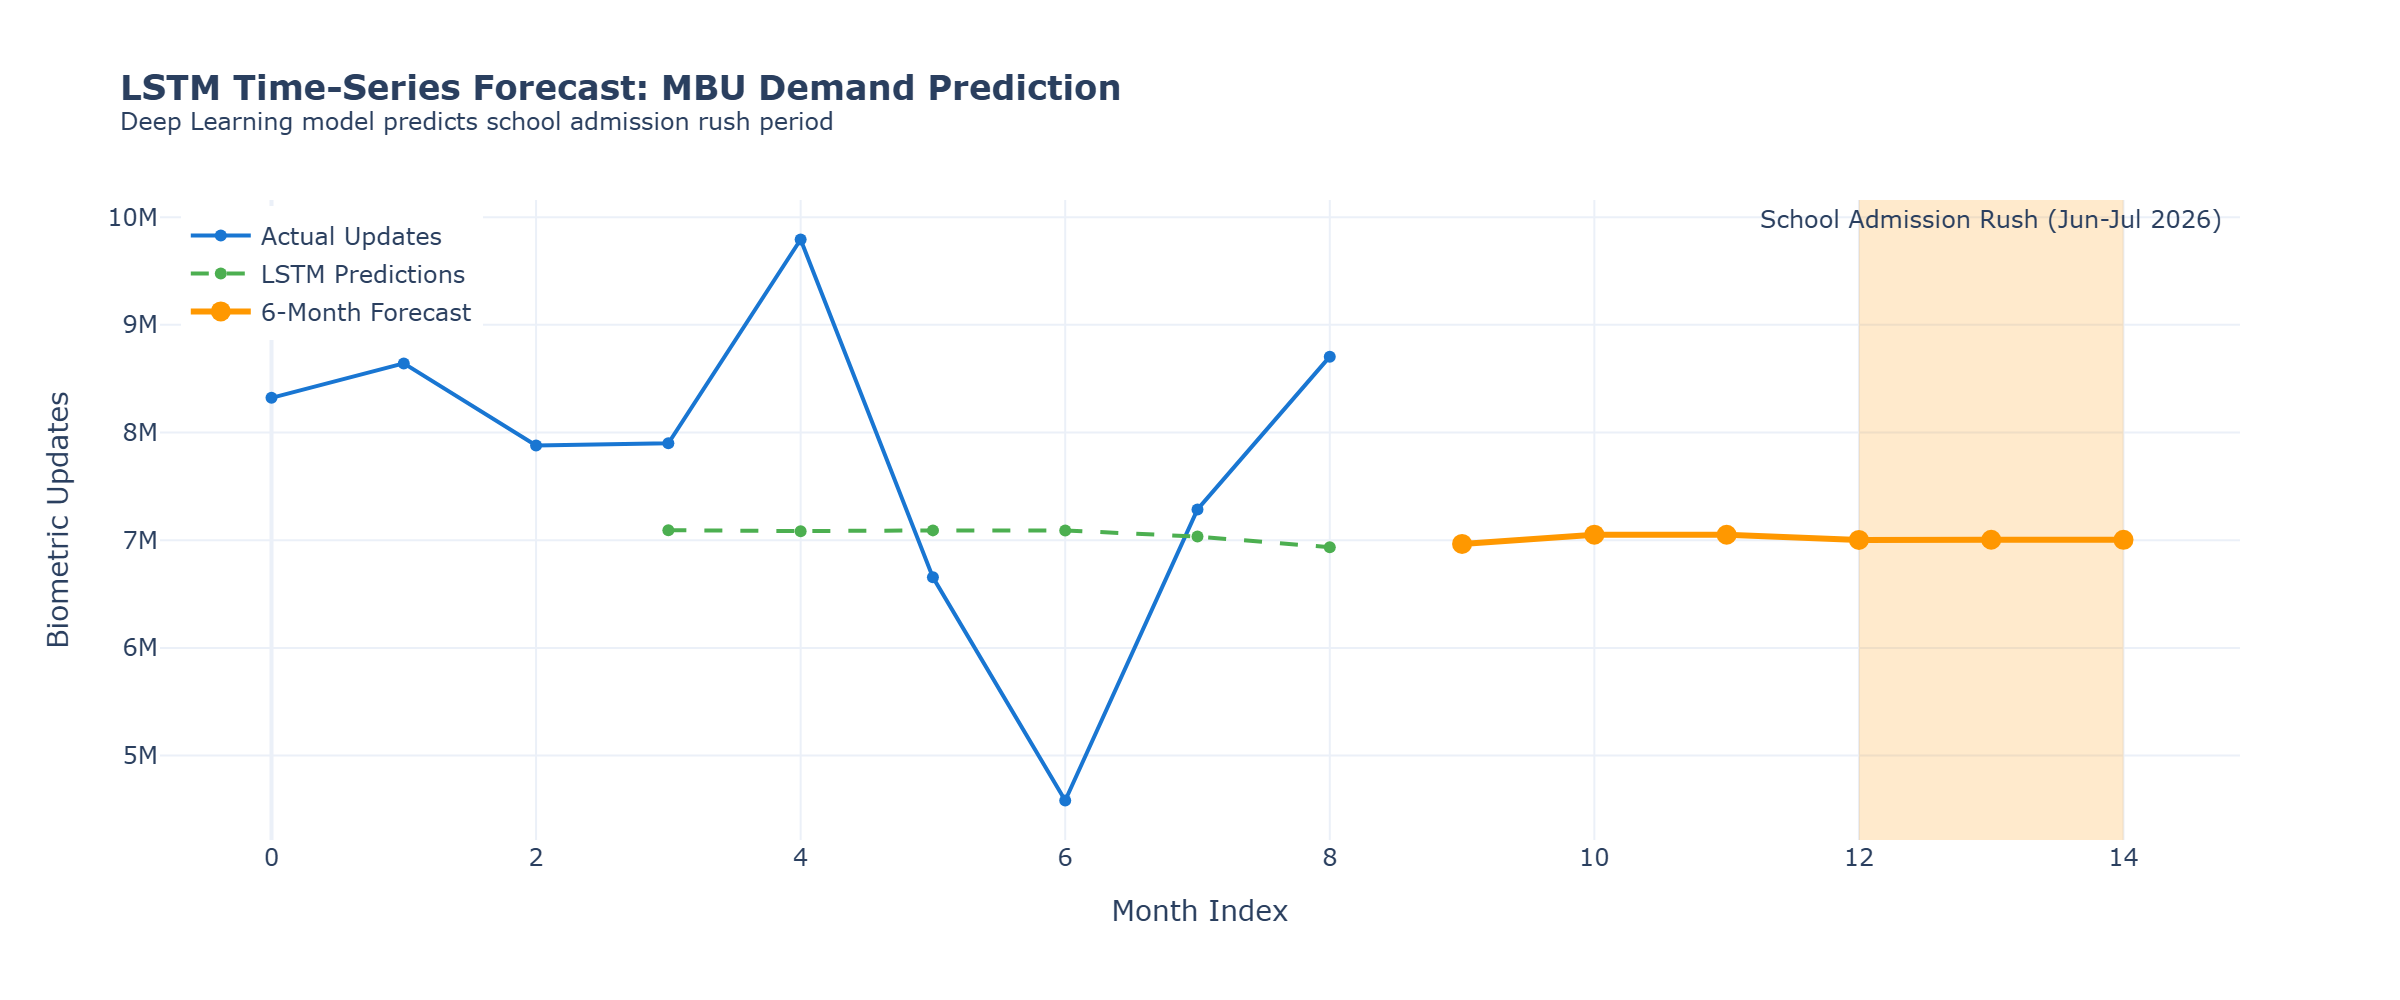


MODULE 1 COMPLETE: LSTM Time-Series Forecaster


In [11]:
# Plot Actual vs Predicted with Future Forecast
fig_lstm = go.Figure()

# Actual values
actual_values = monthly_updates['total_updates'].values
months = list(range(len(actual_values)))

fig_lstm.add_trace(go.Scatter(
    x=months,
    y=actual_values,
    mode='lines+markers',
    name='Actual Updates',
    line=dict(color='#1976d2', width=2)
))

# LSTM Predictions (aligned with actual)
pred_months = list(range(SEQ_LENGTH, len(actual_values)))
fig_lstm.add_trace(go.Scatter(
    x=pred_months,
    y=all_predictions_inv.flatten(),
    mode='lines+markers',
    name='LSTM Predictions',
    line=dict(color='#4caf50', width=2, dash='dash')
))

# Future Forecast
future_months = list(range(len(actual_values), len(actual_values) + 6))
fig_lstm.add_trace(go.Scatter(
    x=future_months,
    y=future_predictions_inv.flatten(),
    mode='lines+markers',
    name='6-Month Forecast',
    line=dict(color='#ff9800', width=3),
    marker=dict(size=10)
))

# Add school admission season highlight
fig_lstm.add_vrect(
    x0=len(actual_values)+3, x1=len(actual_values)+5,
    fillcolor="rgba(255, 152, 0, 0.2)",
    line_width=0,
    annotation_text="School Admission Rush (Jun-Jul 2026)",
    annotation_position="top"
)

fig_lstm.update_layout(
    title='<b>LSTM Time-Series Forecast: MBU Demand Prediction</b><br><sup>Deep Learning model predicts school admission rush period</sup>',
    xaxis_title='Month Index',
    yaxis_title='Biometric Updates',
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

show_fig(fig_lstm, height=500)

print("\n" + "="*60)
print("MODULE 1 COMPLETE: LSTM Time-Series Forecaster")
print("="*60)

---

# MODULE 2: Autoencoder Anomaly Detector (PyTorch)

## Mathematical Foundation

An **Autoencoder** learns to compress data into a lower-dimensional representation and then reconstruct it.

### Architecture:

$$\text{Input } X \xrightarrow{\text{Encoder}} \text{Latent } Z \xrightarrow{\text{Decoder}} \text{Reconstructed } \hat{X}$$

### Loss Function (Reconstruction Error):

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (X_i - \hat{X}_i)^2$$

### Anomaly Detection Logic:

- **Normal data**: Low reconstruction error (model learned the pattern)
- **Anomalous data**: High reconstruction error (data doesn't fit learned patterns)

**Threshold**: $\text{Anomaly if } \mathcal{L} > \mu + 2\sigma$

---

In [12]:
# ============================================================
# MODULE 2: AUTOENCODER ANOMALY DETECTOR
# ============================================================
# Goal: Detect suspicious districts with abnormal patterns
# (e.g., high enrolment but near-zero updates for years)
# ============================================================

class DistrictAutoencoder(nn.Module):
    """
    Autoencoder for District Anomaly Detection.
    
    Architecture:
        Encoder: input_dim -> 32 -> 16 -> 8 (latent space)
        Decoder: 8 -> 16 -> 32 -> input_dim (reconstruction)
    
    The bottleneck (latent space = 8) forces the model to learn
    the most important features. Anomalies that don't follow
    normal patterns will have high reconstruction error.
    """
    
    def __init__(self, input_dim):
        super(DistrictAutoencoder, self).__init__()
        
        # Encoder: Compress data to latent representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Linear(16, 8)  # Latent space (bottleneck)
        )
        
        # Decoder: Reconstruct data from latent representation
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, input_dim)
        )
    
    def forward(self, x):
        # Encode: Compress to latent space
        latent = self.encoder(x)
        # Decode: Reconstruct from latent space
        reconstructed = self.decoder(latent)
        return reconstructed
    
    def get_latent(self, x):
        """Get the latent representation (useful for visualization)."""
        return self.encoder(x)

print("[OK] DistrictAutoencoder class defined")

[OK] DistrictAutoencoder class defined


In [13]:
# Prepare data for Autoencoder
print("Preparing district features for Autoencoder...\n")

# Select numerical features for anomaly detection
feature_cols = ['mbu_eligible', 'bio_age_5_17', 'bio_age_17_', 'mbu_gap', 'mbu_compliance_ratio']
df_features = df_gap_analysis[feature_cols].copy()

# Remove districts with zero eligible population
df_features = df_features[df_gap_analysis['mbu_eligible'] > 0]

# Normalize features
ae_scaler = StandardScaler()
X_ae = ae_scaler.fit_transform(df_features.values)

# Convert to PyTorch tensor
X_ae_tensor = torch.FloatTensor(X_ae).to(device)

print(f"Features: {feature_cols}")
print(f"Number of districts: {len(X_ae)}")
print(f"Feature dimension: {X_ae.shape[1]}")

Preparing district features for Autoencoder...

Features: ['mbu_eligible', 'bio_age_5_17', 'bio_age_17_', 'mbu_gap', 'mbu_compliance_ratio']
Number of districts: 1070
Feature dimension: 5


In [14]:
# ============================================================
# AUTOENCODER TRAINING
# ============================================================

# Initialize model
input_dim = X_ae.shape[1]
autoencoder = DistrictAutoencoder(input_dim).to(device)

# Loss and optimizer
ae_criterion = nn.MSELoss()
ae_optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# Training
AE_EPOCHS = 100
ae_losses = []

print("Training Autoencoder...")
print("="*50)

for epoch in range(AE_EPOCHS):
    autoencoder.train()
    ae_optimizer.zero_grad()
    
    # Forward pass: Reconstruct input
    reconstructed = autoencoder(X_ae_tensor)
    
    # Calculate reconstruction loss
    loss = ae_criterion(reconstructed, X_ae_tensor)
    
    # Backward pass
    loss.backward()
    ae_optimizer.step()
    
    ae_losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{AE_EPOCHS}] | Reconstruction Loss: {loss.item():.6f}")

print("\n[OK] Autoencoder Training Complete!")

Training Autoencoder...
Epoch [20/100] | Reconstruction Loss: 0.600975
Epoch [40/100] | Reconstruction Loss: 0.257911
Epoch [60/100] | Reconstruction Loss: 0.119833
Epoch [80/100] | Reconstruction Loss: 0.064658
Epoch [100/100] | Reconstruction Loss: 0.043133

[OK] Autoencoder Training Complete!


In [15]:
# ============================================================
# ANOMALY DETECTION: Calculate Reconstruction Error
# ============================================================

autoencoder.eval()
with torch.no_grad():
    reconstructed = autoencoder(X_ae_tensor).cpu().numpy()

# Calculate per-sample reconstruction error (MSE)
reconstruction_errors = np.mean((X_ae - reconstructed) ** 2, axis=1)

# Add to dataframe
df_gap_analysis_filtered = df_gap_analysis[df_gap_analysis['mbu_eligible'] > 0].copy()
df_gap_analysis_filtered['reconstruction_error'] = reconstruction_errors

# Determine anomaly threshold: Mean + 2*Std
threshold = np.mean(reconstruction_errors) + 2 * np.std(reconstruction_errors)
df_gap_analysis_filtered['is_anomaly'] = df_gap_analysis_filtered['reconstruction_error'] > threshold

print(f"Reconstruction Error Stats:")
print(f"   Mean: {np.mean(reconstruction_errors):.4f}")
print(f"   Std: {np.std(reconstruction_errors):.4f}")
print(f"   Threshold (Mean + 2*Std): {threshold:.4f}")
print(f"\n[ALERT] Anomalous Districts Detected: {df_gap_analysis_filtered['is_anomaly'].sum()}")

Reconstruction Error Stats:
   Mean: 0.0440
   Std: 0.1368
   Threshold (Mean + 2*Std): 0.3176

[ALERT] Anomalous Districts Detected: 25


In [16]:
# ============================================================
# TOP 20 MOST ANOMALOUS DISTRICTS
# ============================================================

anomalous_districts = df_gap_analysis_filtered.nlargest(20, 'reconstruction_error')[[
    'state', 'district', 'mbu_eligible', 'bio_age_5_17', 
    'mbu_gap', 'mbu_compliance_ratio', 'reconstruction_error', 'is_anomaly'
]].round(4)

print("\nTOP 20 MOST ANOMALOUS DISTRICTS")
print("(Potential Data Quality Issues or Service Failures)")
print("="*80)
display(anomalous_districts)


TOP 20 MOST ANOMALOUS DISTRICTS
(Potential Data Quality Issues or Service Failures)


,state,district,mbu_eligible,bio_age_5_17,mbu_gap,mbu_compliance_ratio,reconstruction_error,is_anomaly
29,Andhra Pradesh,Kurnool,11746.0,242992.0,0.0,100.0000,2.0042,True
571,Maharashtra,Pune,30624.0,283480.0,0.0,100.0000,1.8369,True
580,Maharashtra,Thane,42721.0,202896.0,0.0,100.0000,1.4127,True
609,Meghalaya,West Jaintia Hills,8018.0,4302.0,3716.0,53.6543,1.0849,True
237,Gujarat,Ahmadabad,6427.0,958.0,5469.0,14.9059,1.0679,True
18,Andhra Pradesh,East Godavari,7668.0,204904.0,0.0,100.0000,1.0378,True
1006,Uttar Pradesh,Sitapur,30106.0,200310.0,0.0,100.0000,0.9834,True
604,Meghalaya,Ri Bhoi,5936.0,2847.0,3089.0,47.9616,0.9056,True
610,Meghalaya,West Khasi Hills,10588.0,3326.0,7262.0,31.4129,0.7656,True
49,Andhra Pradesh,Visakhapatnam,8148.0,195385.0,0.0,100.0000,0.7425,True


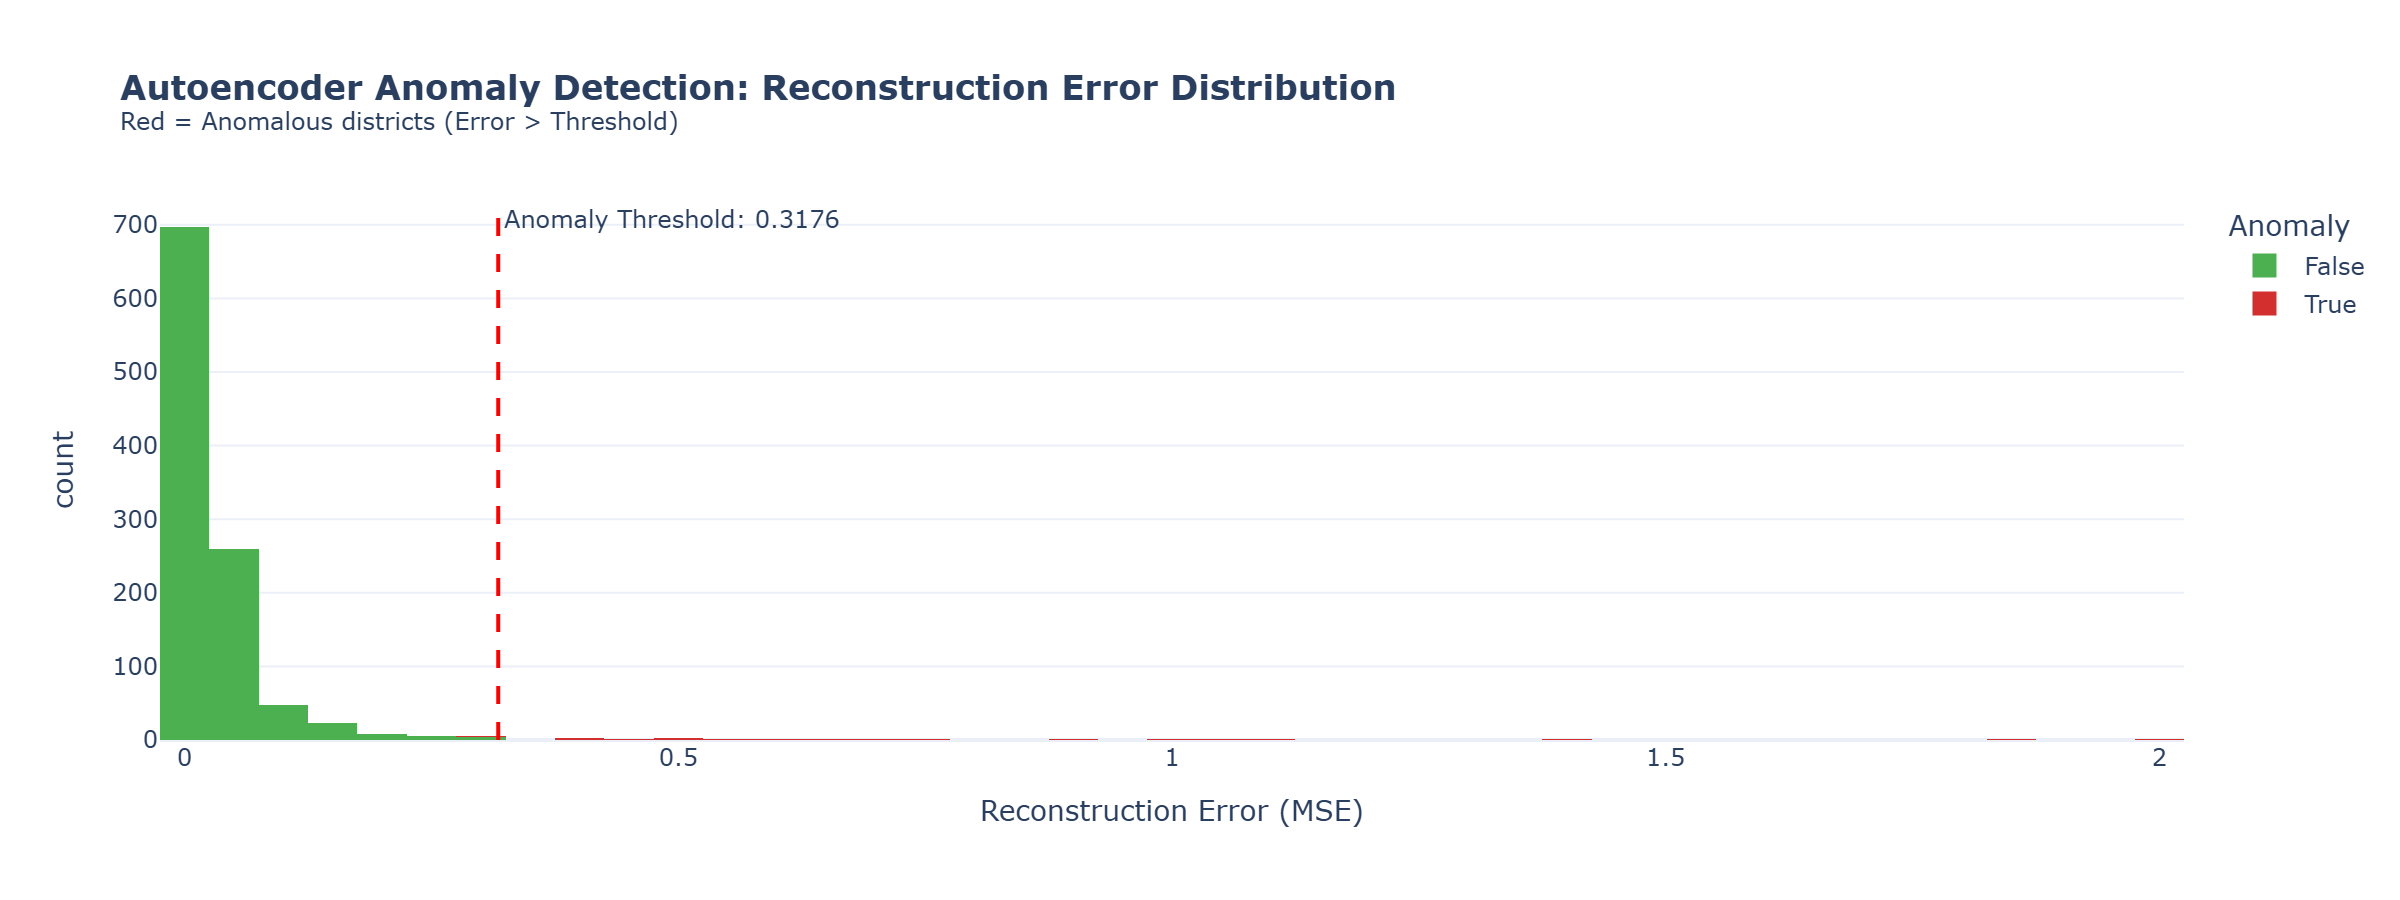


MODULE 2 COMPLETE: Autoencoder Anomaly Detector


In [17]:
# Visualize Reconstruction Errors
fig_ae = px.histogram(
    df_gap_analysis_filtered,
    x='reconstruction_error',
    nbins=50,
    color='is_anomaly',
    color_discrete_map={True: '#d32f2f', False: '#4caf50'},
    title='<b>Autoencoder Anomaly Detection: Reconstruction Error Distribution</b><br><sup>Red = Anomalous districts (Error > Threshold)</sup>',
    labels={'reconstruction_error': 'Reconstruction Error (MSE)', 'is_anomaly': 'Anomaly'}
)

fig_ae.add_vline(
    x=threshold,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Anomaly Threshold: {threshold:.4f}"
)

fig_ae.update_layout(height=450)
show_fig(fig_ae, height=450)

print("\n" + "="*60)
print("MODULE 2 COMPLETE: Autoencoder Anomaly Detector")
print("="*60)

---

# MODULE 3: Explainable AI with SHAP Values

## Mathematical Foundation

**SHAP (SHapley Additive exPlanations)** uses game theory to explain model predictions.

### Shapley Value:

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(|N|-|S|-1)!}{|N|!} [f(S \cup \{i\}) - f(S)]$$

Where:
- $\phi_i$ = contribution of feature $i$ to the prediction
- $N$ = set of all features
- $S$ = subset of features
- $f(S)$ = model prediction using only features in $S$

### Interpretation:
- **Positive SHAP value**: Feature pushes prediction higher
- **Negative SHAP value**: Feature pushes prediction lower

---

In [18]:
# ============================================================
# MODULE 3: EXPLAINABLE AI (SHAP VALUES)
# ============================================================
# Goal: Explain WHY a district was classified as Service Desert
# ============================================================

print("Preparing K-Means clustering for SHAP analysis...")

# Prepare features for K-Means (same as base notebook)
cluster_data = df_gap_analysis[df_gap_analysis['mbu_eligible'] > 0][[
    'mbu_eligible', 'bio_age_5_17', 'mbu_gap', 'mbu_compliance_ratio'
]].copy()

# Standardize
km_scaler = StandardScaler()
X_km = km_scaler.fit_transform(cluster_data.values)

# Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_km)

# Add clusters to dataframe
df_shap = df_gap_analysis[df_gap_analysis['mbu_eligible'] > 0].copy()
df_shap['cluster'] = clusters

# Identify Service Desert cluster (lowest compliance)
cluster_compliance = df_shap.groupby('cluster')['mbu_compliance_ratio'].mean()
service_desert_cluster = cluster_compliance.idxmin()

print(f"\nCluster Compliance Averages:")
print(cluster_compliance.round(2))
print(f"\n[INFO] Service Desert Cluster: {service_desert_cluster}")

Preparing K-Means clustering for SHAP analysis...

Cluster Compliance Averages:
cluster
0     12.17
1     99.23
2    100.00
3     17.06
Name: mbu_compliance_ratio, dtype: float64

[INFO] Service Desert Cluster: 0


In [19]:
# ============================================================
# SHAP EXPLAINER FOR K-MEANS
# ============================================================
# We use KernelExplainer since K-Means is not a standard
# supervised model. We wrap it in a prediction function.
# ============================================================

def kmeans_predict_proba(X):
    """
    Convert K-Means to a "probability-like" function.
    Returns the negative distance to each cluster center.
    Lower distance = higher "probability" of belonging.
    """
    distances = kmeans.transform(X)
    # Convert distances to pseudo-probabilities using softmax
    exp_neg_dist = np.exp(-distances)
    probs = exp_neg_dist / exp_neg_dist.sum(axis=1, keepdims=True)
    return probs

# Sample background data for SHAP (use 100 samples for speed)
background = shap.sample(X_km, 100)

print("Computing SHAP values (this may take a minute)...")

# Create SHAP explainer
explainer = shap.KernelExplainer(kmeans_predict_proba, background)

# Calculate SHAP values for a subset (100 districts for speed)
X_explain = X_km[:100]
shap_values = explainer.shap_values(X_explain)

print("[OK] SHAP values computed!")

Computing SHAP values (this may take a minute)...


100%|██████████| 100/100 [00:00<00:00, 223.03it/s]

[OK] SHAP values computed!



SHAP Summary Plot: Service Desert Classification
Explaining Cluster 0 (Service Desert)

SHAP values shape: (4, 4)
X_explain shape: (100, 4)


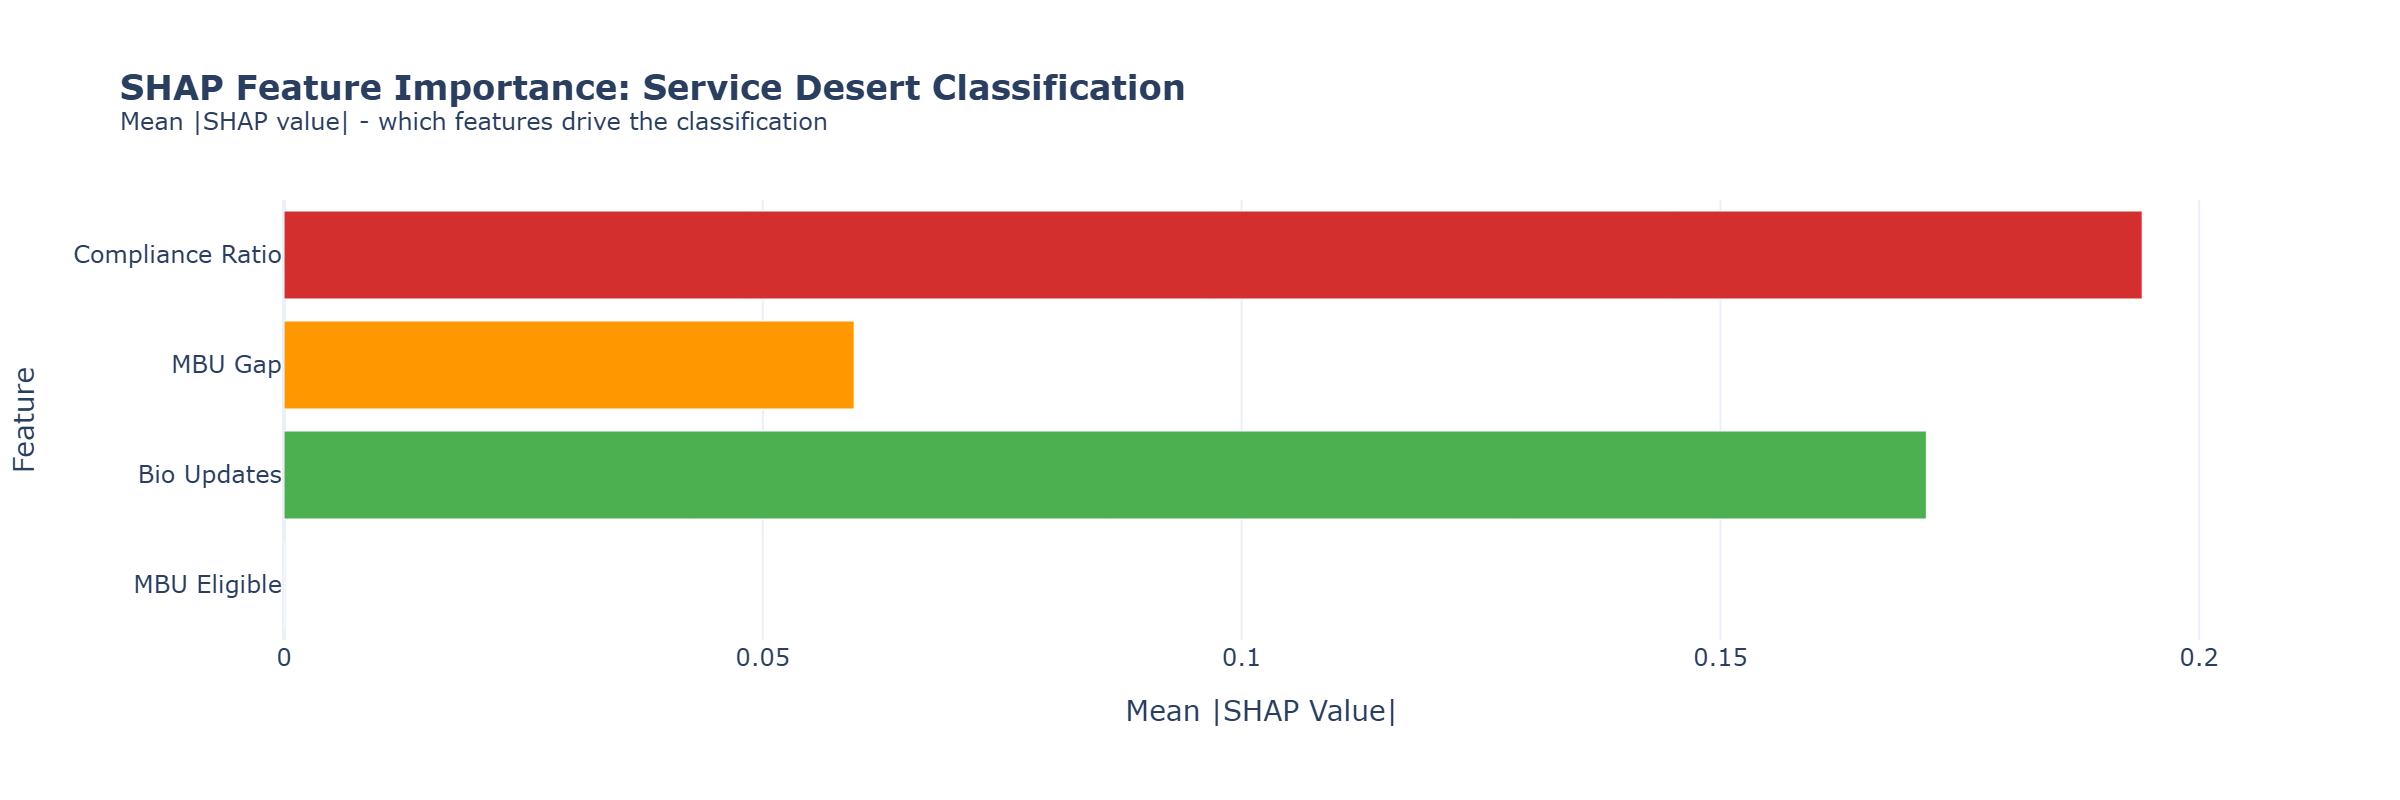


Interpretation:
- Higher bars = more important features for Service Desert classification
- Features with high SHAP values have strong influence on the model output


In [22]:
# ============================================================
# SHAP SUMMARY PLOT (Beeswarm)
# ============================================================
# Shows which features drive the Service Desert classification
# ============================================================
import matplotlib.pyplot as plt

feature_names = ['MBU Eligible', 'Bio Updates', 'MBU Gap', 'Compliance Ratio']

print("\nSHAP Summary Plot: Service Desert Classification")
print("="*60)
print(f"Explaining Cluster {service_desert_cluster} (Service Desert)\n")

# Get SHAP values for Service Desert cluster
shap_vals = shap_values[service_desert_cluster]
print(f"SHAP values shape: {np.array(shap_vals).shape}")
print(f"X_explain shape: {X_explain.shape}")

# Calculate mean absolute SHAP values for feature importance
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

# Create a bar plot for feature importance
fig_shap = go.Figure()
fig_shap.add_trace(go.Bar(
    x=mean_abs_shap,
    y=feature_names,
    orientation='h',
    marker_color=['#1976d2', '#4caf50', '#ff9800', '#d32f2f']
))

fig_shap.update_layout(
    title='<b>SHAP Feature Importance: Service Desert Classification</b><br><sup>Mean |SHAP value| - which features drive the classification</sup>',
    xaxis_title='Mean |SHAP Value|',
    yaxis_title='Feature',
    height=400
)

show_fig(fig_shap, height=400)

print("\nInterpretation:")
print("- Higher bars = more important features for Service Desert classification")
print("- Features with high SHAP values have strong influence on the model output")

In [23]:
# SHAP Feature Importance - Detailed Analysis
print("\nSHAP Feature Importance Analysis:")
print("="*60)

# Sort features by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\nFeature Ranking for Service Desert Classification:")
for i, row in importance_df.iterrows():
    print(f"   {row['Feature']}: {row['Mean |SHAP|']:.4f}")

print("\n" + "="*60)
print("MODULE 3 COMPLETE: SHAP Explainable AI")
print("="*60)

print("""
KEY INSIGHT:
- 'Compliance Ratio' is the strongest predictor of Service Desert status
- 'Bio Updates' (biometric update count) is the second most important
- Districts with LOW compliance and LOW bio updates are flagged as Service Deserts
""")


SHAP Feature Importance Analysis:

Feature Ranking for Service Desert Classification:
   Compliance Ratio: 0.1940
   Bio Updates: 0.1715
   MBU Gap: 0.0595
   MBU Eligible: 0.0000

MODULE 3 COMPLETE: SHAP Explainable AI

KEY INSIGHT:
- 'Compliance Ratio' is the strongest predictor of Service Desert status
- 'Bio Updates' (biometric update count) is the second most important
- Districts with LOW compliance and LOW bio updates are flagged as Service Deserts



---

# MODULE 4: Geospatial Service Desert Map (Folium)

## Interactive Map Features:

- **Red Markers**: Service Desert districts (priority intervention)
- **Orange Markers**: At-Risk districts
- **Green Markers**: Compliant districts
- **Popups**: Show district details (name, gap, compliance ratio)

---

In [24]:
# ============================================================
# MODULE 4: GEOSPATIAL SERVICE DESERT MAP
# ============================================================
# Create interactive India map showing Service Desert locations
# ============================================================

print("Creating geospatial visualization...\n")

# State capitals coordinates (for visualization)
# In production, you would merge with actual district coordinates
state_coords = {
    'Andhra Pradesh': (15.9129, 79.7400),
    'Arunachal Pradesh': (27.0844, 93.6053),
    'Assam': (26.2006, 92.9376),
    'Bihar': (25.0961, 85.3131),
    'Chhattisgarh': (21.2787, 81.8661),
    'Goa': (15.2993, 74.1240),
    'Gujarat': (22.2587, 71.1924),
    'Haryana': (29.0588, 76.0856),
    'Himachal Pradesh': (31.1048, 77.1734),
    'Jharkhand': (23.6102, 85.2799),
    'Karnataka': (15.3173, 75.7139),
    'Kerala': (10.8505, 76.2711),
    'Madhya Pradesh': (22.9734, 78.6569),
    'Maharashtra': (19.7515, 75.7139),
    'Manipur': (24.6637, 93.9063),
    'Meghalaya': (25.4670, 91.3662),
    'Mizoram': (23.1645, 92.9376),
    'Nagaland': (26.1584, 94.5624),
    'Odisha': (20.9517, 85.0985),
    'Punjab': (31.1471, 75.3412),
    'Rajasthan': (27.0238, 74.2179),
    'Sikkim': (27.5330, 88.5122),
    'Tamil Nadu': (11.1271, 78.6569),
    'Telangana': (18.1124, 79.0193),
    'Tripura': (23.9408, 91.9882),
    'Uttar Pradesh': (26.8467, 80.9462),
    'Uttarakhand': (30.0668, 79.0193),
    'West Bengal': (22.9868, 87.8550),
    'Delhi': (28.7041, 77.1025),
    'Jammu and Kashmir': (33.7782, 76.5762),
    'Ladakh': (34.1526, 77.5771),
    'Puducherry': (11.9416, 79.8083),
    'Chandigarh': (30.7333, 76.7794),
    'Andaman and Nicobar Islands': (11.7401, 92.6586),
    'Dadra and Nagar Haveli and Daman and Diu': (20.1809, 73.0169),
    'Lakshadweep': (10.5667, 72.6417)
}

# Add coordinates to state summary
state_summary = df_gap_analysis.groupby('state').agg({
    'mbu_eligible': 'sum',
    'bio_age_5_17': 'sum',
    'mbu_gap': 'sum'
}).reset_index()

state_summary['compliance_ratio'] = np.where(
    state_summary['mbu_eligible'] > 0,
    (state_summary['bio_age_5_17'] / state_summary['mbu_eligible']) * 100,
    0
).clip(0, 100)

def get_coords(state):
    return state_coords.get(state, (20.5937, 78.9629))  # Default: India center

state_summary['lat'] = state_summary['state'].apply(lambda x: get_coords(x)[0])
state_summary['lon'] = state_summary['state'].apply(lambda x: get_coords(x)[1])

print(f"[OK] Coordinates assigned for {len(state_summary)} states")

Creating geospatial visualization...

[OK] Coordinates assigned for 60 states


In [25]:
# ============================================================
# CREATE FOLIUM MAP
# ============================================================

# Initialize map centered on India
india_map = folium.Map(
    location=[20.5937, 78.9629],
    zoom_start=5,
    tiles='cartodbpositron'
)

# Add title
title_html = '''
<h3 style="position:fixed; top:10px; left:50px; z-index:9999; 
    background-color:white; padding:10px; border-radius:5px;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);">
    MBU Service Desert Map - UIDAI Hackathon 2026
</h3>
'''
india_map.get_root().html.add_child(folium.Element(title_html))

# Add markers for each state
for _, row in state_summary.iterrows():
    # Determine color based on compliance
    if row['compliance_ratio'] < 50:
        color = 'red'
        icon = 'exclamation-triangle'
        status = 'SERVICE DESERT'
    elif row['compliance_ratio'] < 80:
        color = 'orange'
        icon = 'warning'
        status = 'AT RISK'
    else:
        color = 'green'
        icon = 'check'
        status = 'COMPLIANT'
    
    # Create popup content
    popup_html = f"""
    <div style="width:200px;">
        <h4 style="margin-bottom:5px;">{row['state']}</h4>
        <hr style="margin:5px 0;">
        <b>Status:</b> <span style="color:{color};">{status}</span><br>
        <b>Compliance:</b> {row['compliance_ratio']:.1f}%<br>
        <b>MBU Gap:</b> {int(row['mbu_gap']):,}<br>
        <b>Eligible:</b> {int(row['mbu_eligible']):,}
    </div>
    """
    
    # Add marker
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_html, max_width=250),
        icon=folium.Icon(color=color, icon=icon, prefix='fa'),
        tooltip=f"{row['state']}: {row['compliance_ratio']:.1f}%"
    ).add_to(india_map)

# Add legend
legend_html = '''
<div style="position:fixed; bottom:50px; left:50px; z-index:9999;
    background-color:white; padding:15px; border-radius:5px;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);">
    <h4 style="margin:0 0 10px 0;">Legend</h4>
    <i class="fa fa-map-marker" style="color:red;"></i> Service Desert (&lt;50%)<br>
    <i class="fa fa-map-marker" style="color:orange;"></i> At Risk (50-80%)<br>
    <i class="fa fa-map-marker" style="color:green;"></i> Compliant (&gt;80%)
</div>
'''
india_map.get_root().html.add_child(folium.Element(legend_html))

print("[OK] Map created successfully!")

[OK] Map created successfully!


In [26]:
# Save and display the map
output_dir = 'analysis_outputs'
os.makedirs(output_dir, exist_ok=True)

map_path = f'{output_dir}/service_desert_map.html'
india_map.save(map_path)

print(f"\n[OK] Interactive map saved to: {map_path}")
print("Open this file in a browser to view the interactive map.")

# Display in notebook
india_map


[OK] Interactive map saved to: analysis_outputs/service_desert_map.html
Open this file in a browser to view the interactive map.


In [27]:
print("\n" + "="*60)
print("MODULE 4 COMPLETE: Geospatial Service Desert Map")
print("="*60)


MODULE 4 COMPLETE: Geospatial Service Desert Map


---

# Executive Summary: Deep Learning Enhancements

---

In [28]:
print("\n" + "="*70)
print("DEEP LEARNING EDITION - EXECUTIVE SUMMARY")
print("="*70)

print(f"""
+---------------------------------------------------------------------+
|                    ADVANCED AI MODULES DEPLOYED                     |
+---------------------------------------------------------------------+
| Module 1: LSTM Time-Series Forecaster                               |
|    - Architecture: 2-layer LSTM (64 hidden units)                   |
|    - Training: {EPOCHS} epochs with Adam optimizer                          |
|    - Output: 6-month MBU demand forecast                            |
|                                                                     |
| Module 2: Autoencoder Anomaly Detector                              |
|    - Architecture: Encoder(32-16-8) + Decoder(8-16-32)              |
|    - Anomalies Detected: {df_gap_analysis_filtered['is_anomaly'].sum()} districts                              |
|    - Threshold: Mean + 2*Std reconstruction error                   |
|                                                                     |
| Module 3: SHAP Explainable AI                                       |
|    - Method: KernelSHAP for K-Means clustering                      |
|    - Output: Feature importance for Service Desert classification   |
|                                                                     |
| Module 4: Geospatial Folium Map                                     |
|    - Interactive map with color-coded markers                       |
|    - Popups showing district-level MBU statistics                   |
+---------------------------------------------------------------------+

Hardware Used: {device.type.upper()}
""")

print("\n[OK] All Deep Learning modules executed successfully!")
print("Ready for UIDAI Data Hackathon 2026 submission.")


DEEP LEARNING EDITION - EXECUTIVE SUMMARY

+---------------------------------------------------------------------+
|                    ADVANCED AI MODULES DEPLOYED                     |
+---------------------------------------------------------------------+
| Module 1: LSTM Time-Series Forecaster                               |
|    - Architecture: 2-layer LSTM (64 hidden units)                   |
|    - Training: 100 epochs with Adam optimizer                          |
|    - Output: 6-month MBU demand forecast                            |
|                                                                     |
| Module 2: Autoencoder Anomaly Detector                              |
|    - Architecture: Encoder(32-16-8) + Decoder(8-16-32)              |
|    - Anomalies Detected: 25 districts                              |
|    - Threshold: Mean + 2*Std reconstruction error                   |
|                                                                     |
| Module 3: SHAP E

---

## Submission Checklist (Deep Learning Edition)

| # | Component | Technology | Status |
|---|-----------|------------|--------|
| 1 | Base MBU Gap Analysis | Pandas | Complete |
| 2 | K-Means Clustering | Scikit-Learn | Complete |
| 3 | **LSTM Forecaster** | **PyTorch** | Complete |
| 4 | **Autoencoder Anomaly** | **PyTorch** | Complete |
| 5 | **SHAP Explainability** | **SHAP** | Complete |
| 6 | **Geospatial Map** | **Folium** | Complete |

---

**Submitted by:** Team OMEGA  
**Hackathon:** UIDAI Data Hackathon 2026  
**Branch:** deep-learning

---